# Physically Motivated Feature Engineering

This notebook evaluates new communication-specific features motivated
directly by the failure modes identified in the previous error analysis.

The objective is to determine whether improving the signal representation
provides a larger benefit than increasing classifier complexity.

The new descriptors target four physical properties:

1. angular symmetry for PSK modulation order;
2. radial constellation structure for QAM modulation order;
3. envelope and instantaneous-frequency dynamics for AM/FM separation;
4. rotation-invariant I/Q geometry.

All model-selection experiments are performed using the training split
and cross-validation.

The validation and test splits remain untouched during feature selection.

In [33]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

DATA_PATH = Path(
    "../data/raw/RML2016.10a/RML2016.10a_dict.pkl"
)

print("Dataset path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

# --------------------------------------------------
# Project paths
# --------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR)
    )


# --------------------------------------------------
# Project modules
# --------------------------------------------------

import rfml.features

importlib.reload(
    rfml.features
)


print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "Source directory:",
    SRC_DIR
)

print(
    "Features module:",
    rfml.features.__file__
)

Dataset path: ..\data\raw\RML2016.10a\RML2016.10a_dict.pkl
Exists: True
Project root: c:\Users\joset\Projects\snr-aware-modulation-classification
Source directory: c:\Users\joset\Projects\snr-aware-modulation-classification\src
Features module: c:\Users\joset\Projects\snr-aware-modulation-classification\src\rfml\features.py


In [12]:
with open(DATA_PATH, "rb") as f:
    radioml = pickle.load(
        f,
        encoding="latin1"
    )

print(
    "Dataset loaded correctly."
)

print(
    "Number of keys:",
    len(radioml)
)

Dataset loaded correctly.
Number of keys: 220


In [13]:
print(
    hasattr(
        rfml.features,
        "extract_physical_features"
    )
)

print(
    hasattr(
        rfml.features,
        "extract_features"
    )
)

True
True


## 2. Smoke test of the physical features

Before extracting the new descriptors for the complete training dataset,
the implementation is tested on a single high-SNR signal.

A QPSK sample at 18 dB is used first because the signal structure should
be clearly observable in this regime.

The objectives are to verify:

- the expected number of physical features;
- finite numerical values;
- plausible numerical ranges;
- preservation of the original 28-feature baseline.

In [14]:
sample = radioml[
    ("QPSK", 18)
][0]

print("Shape:", sample.shape)
print("dtype:", sample.dtype)

Shape: (2, 128)
dtype: float32


In [15]:
physical_features = (
    rfml.features.extract_physical_features(
        sample
    )
)

print(
    "Physical feature count:",
    len(physical_features)
)

Physical feature count: 19


In [16]:
for name, value in physical_features.items():
    print(
        f"{name:35s} "
        f"{value: .6f}"
    )

circular_moment_2                    0.127769
circular_moment_4                    0.491307
circular_moment_8                    0.272449
circularity_coeff                    0.111883
iq_anisotropy                        0.167266
amplitude_m4                         1.277342
amplitude_m6                         1.829562
radial_q25                           0.785028
radial_q50                           1.008057
radial_q75                           1.176591
radial_iqr                           0.391563
c40_normalized                       0.830401
c42_normalized                      -0.735015
envelope_diff_std                    0.148007
envelope_autocorr_lag1               0.894800
phase_diff_resultant                 0.953594
inst_freq_diff_std                   0.253081
inst_freq_autocorr_lag1              0.684189
spectral_sideband_asymmetry          0.070529


In [17]:
physical_values = np.array(
    list(
        physical_features.values()
    ),
    dtype=float,
)

print(
    "All finite:",
    np.all(
        np.isfinite(
            physical_values
        )
    )
)

print(
    "NaN count:",
    np.isnan(
        physical_values
    ).sum()
)

print(
    "Inf count:",
    np.isinf(
        physical_values
    ).sum()
)

All finite: True
NaN count: 0
Inf count: 0


In [18]:
baseline_features = (
    rfml.features.extract_features(
        sample,
        feature_set="full",
    )
)

extended_features = (
    rfml.features.extract_features(
        sample,
        feature_set="full_physical",
    )
)

print(
    "Baseline feature count:",
    len(baseline_features)
)

print(
    "Extended feature count:",
    len(extended_features)
)

Baseline feature count: 28
Extended feature count: 47


In [19]:
baseline_names = set(
    baseline_features.keys()
)

extended_names = set(
    extended_features.keys()
)

print(
    "All baseline features preserved:",
    baseline_names.issubset(
        extended_names
    )
)

new_feature_names = sorted(
    extended_names
    - baseline_names
)

print(
    "Number of new features:",
    len(new_feature_names)
)

print()

for name in new_feature_names:
    print(name)

All baseline features preserved: True
Number of new features: 19

amplitude_m4
amplitude_m6
c40_normalized
c42_normalized
circular_moment_2
circular_moment_4
circular_moment_8
circularity_coeff
envelope_autocorr_lag1
envelope_diff_std
inst_freq_autocorr_lag1
inst_freq_diff_std
iq_anisotropy
phase_diff_resultant
radial_iqr
radial_q25
radial_q50
radial_q75
spectral_sideband_asymmetry


## 3. Preliminary train-only feature test

Before extracting the 47-feature representation for the complete training
split, the new descriptors are evaluated on a smaller stratified subset
of training samples.

The objective is to verify whether each physically motivated feature block
improves the specific modulation pair it was designed to represent.

Only training samples are used in this experiment.

In [20]:
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

train_metadata = pd.read_csv(
    PROCESSED_DIR
    / "train_metadata.csv"
)

print(
    "Train metadata:",
    train_metadata.shape
)

train_metadata.head()

Train metadata: (154000, 4)


,sample_id,modulation,snr,array_index
0,76262,BPSK,12,262
1,22989,AM-DSB,-16,989
2,29876,AM-DSB,-2,876
3,209586,WBFM,-2,586
4,82273,CPFSK,-16,273


In [21]:
target_modulations = [
    "QPSK",
    "8PSK",
    "QAM16",
    "QAM64",
    "WBFM",
    "AM-DSB",
]

In [22]:
selected_snrs = [
    -10,
    0,
    8,
    18,
]

In [23]:
subset_rows = []

samples_per_group = 150

for modulation in target_modulations:

    for snr in selected_snrs:

        group = train_metadata[
            (
                train_metadata["modulation"]
                == modulation
            )
            &
            (
                train_metadata["snr"]
                == snr
            )
        ]

        sampled_group = group.sample(
            n=samples_per_group,
            random_state=42,
        )

        subset_rows.append(
            sampled_group
        )

physical_test_metadata = pd.concat(
    subset_rows,
    ignore_index=True,
)

print(
    "Subset shape:",
    physical_test_metadata.shape
)

pd.crosstab(
    physical_test_metadata[
        "modulation"
    ],
    physical_test_metadata[
        "snr"
    ],
)

Subset shape: (3600, 4)


snr,-10,0,8,18
modulation,,,,
8PSK,150,150,150,150
AM-DSB,150,150,150,150
QAM16,150,150,150,150
QAM64,150,150,150,150
QPSK,150,150,150,150
WBFM,150,150,150,150


In [24]:
physical_test_features = (
    rfml.features.build_feature_table(
        radioml,
        physical_test_metadata,
        feature_set="full_physical",
    )
)

print(
    "Feature table shape:",
    physical_test_features.shape
)

Feature table shape: (3600, 50)


In [25]:
physical_feature_columns = [
    column
    for column
    in physical_test_features.columns
    if column not in [
        "sample_id",
        "modulation",
        "snr",
    ]
]

print(
    "Number of feature columns:",
    len(physical_feature_columns)
)

Number of feature columns: 47


In [26]:
feature_values = (
    physical_test_features[
        physical_feature_columns
    ]
    .to_numpy(
        dtype=float
    )
)

print(
    "All finite:",
    np.isfinite(
        feature_values
    ).all()
)

print(
    "NaN count:",
    np.isnan(
        feature_values
    ).sum()
)

print(
    "Inf count:",
    np.isinf(
        feature_values
    ).sum()
)

All finite: True
NaN count: 0
Inf count: 0


In [27]:
new_feature_names = [
    "circular_moment_2",
    "circular_moment_4",
    "circular_moment_8",
    "circularity_coeff",
    "iq_anisotropy",
    "amplitude_m4",
    "amplitude_m6",
    "radial_q25",
    "radial_q50",
    "radial_q75",
    "radial_iqr",
    "c40_normalized",
    "c42_normalized",
    "envelope_diff_std",
    "envelope_autocorr_lag1",
    "phase_diff_resultant",
    "inst_freq_diff_std",
    "inst_freq_autocorr_lag1",
    "spectral_sideband_asymmetry",
]

physical_test_features[
    new_feature_names
].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
circular_moment_2,3600.0,0.323,0.329,0.005,0.091,0.172,0.414,1.000
circular_moment_4,3600.0,0.296,0.306,0.001,0.087,0.170,0.365,1.000
circular_moment_8,3600.0,0.238,0.290,0.002,0.069,0.118,0.239,0.999
circularity_coeff,3600.0,0.361,0.324,0.003,0.121,0.223,0.516,1.000
iq_anisotropy,3600.0,0.222,0.191,0.004,0.101,0.163,0.276,0.991
amplitude_m4,3600.0,1.505,0.492,1.000,1.209,1.445,1.757,14.358
amplitude_m6,3600.0,3.299,5.536,1.000,1.620,2.536,4.109,229.987
radial_q25,3600.0,0.711,0.162,0.006,0.577,0.683,0.834,0.997
radial_q50,3600.0,0.932,0.083,0.016,0.877,0.952,1.000,1.115
radial_q75,3600.0,1.151,0.077,0.102,1.128,1.166,1.198,1.329


### 3.7 Robustness of higher-order descriptors

Higher-order moments and cumulants can exhibit large values because they
amplify extreme samples.

Before evaluating their discriminative power, their upper-tail behaviour
is inspected to verify that the observed maxima correspond to isolated
samples rather than numerical instability.

In [28]:
tail_features = [
    "amplitude_m4",
    "amplitude_m6",
    "c40_normalized",
    "c42_normalized",
]

tail_summary = (
    physical_test_features[
        tail_features
    ]
    .quantile(
        [0.50, 0.90, 0.95, 0.99, 1.00]
    )
    .T
)

tail_summary.round(3)

,0.50,0.90,0.95,0.99,1.00
amplitude_m4,1.445,2.031,2.170,2.453,14.358
amplitude_m6,2.536,6.069,7.369,10.716,229.987
c40_normalized,0.518,1.971,1.999,1.999,10.439
c42_normalized,-0.642,0.006,0.148,0.420,11.446


---

## 4. Pair-specific information in the new physical features

The new descriptors were designed to target specific physical ambiguities
identified in the previous error analysis.

Their usefulness is first evaluated directly, before training a new
classifier.

Three pair-specific analyses are performed:

1. QPSK vs 8PSK — angular symmetry features;
2. QAM16 vs QAM64 — radial moments and cumulants;
3. WBFM vs AM-DSB — envelope and instantaneous-frequency dynamics.

The analysis uses only the stratified training subset.

In [29]:
def eta_squared_by_class(
    dataframe,
    feature,
    class_column="modulation",
):
    values = dataframe[
        feature
    ].to_numpy()

    overall_mean = np.mean(
        values
    )

    ss_total = np.sum(
        (values - overall_mean) ** 2
    )

    ss_between = 0.0

    for _, group in dataframe.groupby(
        class_column
    ):
        group_values = (
            group[feature].to_numpy()
        )

        group_mean = np.mean(
            group_values
        )

        ss_between += (
            len(group_values)
            * (group_mean - overall_mean) ** 2
        )

    return (
        ss_between
        / (ss_total + 1e-12)
    )

## 5. QPSK vs 8PSK — angular symmetry

The previous 28-feature representation provided very weak individual
separation between QPSK and 8PSK.

The new circular moments explicitly measure angular symmetry:

\[
\rho_k =
\left|
E\left[
\left(\frac{x}{|x|}\right)^k
\right]
\right|
\]

The fourth- and eighth-order moments are therefore natural candidates
for distinguishing QPSK and 8PSK.

In [30]:
psk_physical_features = [
    "circular_moment_2",
    "circular_moment_4",
    "circular_moment_8",
    "circularity_coeff",
    "iq_anisotropy",
]

In [31]:
psk_eta_rows = []

for snr in selected_snrs:

    subset = physical_test_features[
        (
            physical_test_features["snr"]
            == snr
        )
        &
        (
            physical_test_features[
                "modulation"
            ].isin(
                ["QPSK", "8PSK"]
            )
        )
    ]

    for feature in psk_physical_features:

        eta2 = eta_squared_by_class(
            subset,
            feature,
        )

        psk_eta_rows.append({
            "snr": snr,
            "feature": feature,
            "eta_squared": eta2,
        })

psk_eta_df = pd.DataFrame(
    psk_eta_rows
)

psk_eta_matrix = (
    psk_eta_df
    .pivot(
        index="feature",
        columns="snr",
        values="eta_squared",
    )
)

psk_eta_matrix.round(3)

snr,-10,0,8,18
feature,,,,
circular_moment_2,0.018,0.003,0.001,0.002
circular_moment_4,0.001,0.421,0.748,0.714
circular_moment_8,0.004,0.003,0.107,0.056
circularity_coeff,0.005,0.002,0.015,0.008
iq_anisotropy,0.007,0.001,0.003,0.006


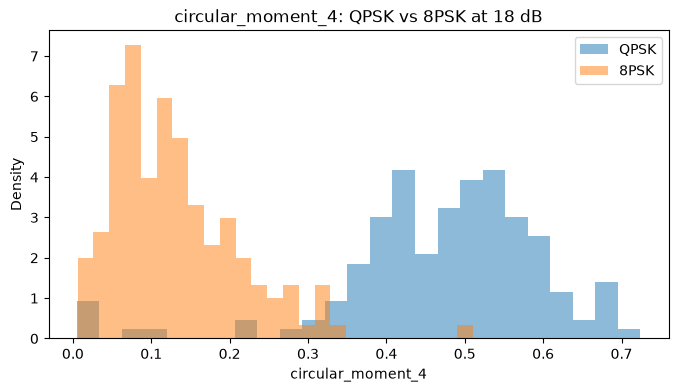

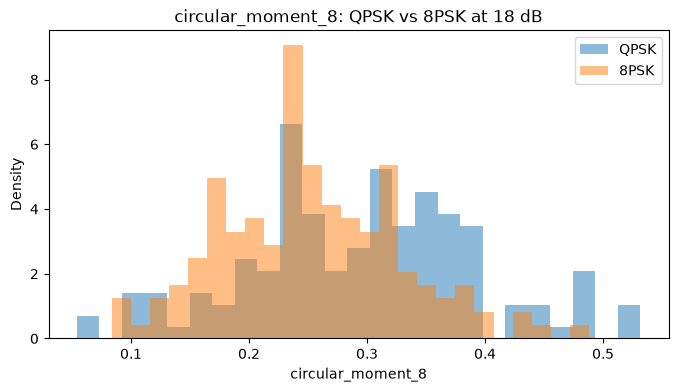

In [34]:
snr_to_plot = 18

for feature in [
    "circular_moment_4",
    "circular_moment_8",
]:

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    for modulation in [
        "QPSK",
        "8PSK",
    ]:

        values = physical_test_features[
            (
                physical_test_features["snr"]
                == snr_to_plot
            )
            &
            (
                physical_test_features[
                    "modulation"
                ]
                == modulation
            )
        ][feature]

        ax.hist(
            values,
            bins=25,
            density=True,
            alpha=0.5,
            label=modulation,
        )

    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

    ax.set_title(
        f"{feature}: QPSK vs 8PSK "
        f"at {snr_to_plot} dB"
    )

    ax.legend()

    plt.show()

## 6. QAM16 vs QAM64 — radial structure

QAM16 and QAM64 differ mainly in the number and distribution of
constellation amplitude levels.

The previous representation summarized amplitude mostly through global
dispersion, extrema and PAPR.

The new descriptors explicitly characterize the radial distribution using
normalized higher-order moments, quantiles and cumulants.

In [35]:
qam_physical_features = [
    "amplitude_m4",
    "amplitude_m6",
    "radial_q25",
    "radial_q50",
    "radial_q75",
    "radial_iqr",
    "c40_normalized",
    "c42_normalized",
]

In [36]:
qam_eta_rows = []

for snr in selected_snrs:

    subset = physical_test_features[
        (
            physical_test_features["snr"]
            == snr
        )
        &
        (
            physical_test_features[
                "modulation"
            ].isin(
                ["QAM16", "QAM64"]
            )
        )
    ]

    for feature in qam_physical_features:

        eta2 = eta_squared_by_class(
            subset,
            feature,
        )

        qam_eta_rows.append({
            "snr": snr,
            "feature": feature,
            "eta_squared": eta2,
        })

qam_eta_df = pd.DataFrame(
    qam_eta_rows
)

qam_eta_matrix = (
    qam_eta_df
    .pivot(
        index="feature",
        columns="snr",
        values="eta_squared",
    )
)

qam_eta_matrix.round(3)

snr,-10,0,8,18
feature,,,,
amplitude_m4,0.143,0.000,0.008,0.000
amplitude_m6,0.125,0.000,0.005,0.002
c40_normalized,0.000,0.001,0.005,0.000
c42_normalized,0.162,0.001,0.010,0.000
radial_iqr,0.010,0.002,0.004,0.006
radial_q25,0.044,0.004,0.004,0.002
radial_q50,0.092,0.020,0.062,0.007
radial_q75,0.009,0.000,0.000,0.002


## 7. WBFM vs AM-DSB — envelope and frequency dynamics

The AM/FM distinction is fundamentally temporal.

AM-DSB primarily encodes information in envelope variations, whereas WBFM
encodes information through instantaneous phase and frequency.

The new descriptors therefore analyse the temporal dynamics of these two
quantities explicitly.

In [37]:
analog_physical_features = [
    "envelope_diff_std",
    "envelope_autocorr_lag1",
    "phase_diff_resultant",
    "inst_freq_diff_std",
    "inst_freq_autocorr_lag1",
    "spectral_sideband_asymmetry",
]

In [38]:
analog_eta_rows = []

for snr in selected_snrs:

    subset = physical_test_features[
        (
            physical_test_features["snr"]
            == snr
        )
        &
        (
            physical_test_features[
                "modulation"
            ].isin(
                ["WBFM", "AM-DSB"]
            )
        )
    ]

    for feature in analog_physical_features:

        eta2 = eta_squared_by_class(
            subset,
            feature,
        )

        analog_eta_rows.append({
            "snr": snr,
            "feature": feature,
            "eta_squared": eta2,
        })

analog_eta_df = pd.DataFrame(
    analog_eta_rows
)

analog_eta_matrix = (
    analog_eta_df
    .pivot(
        index="feature",
        columns="snr",
        values="eta_squared",
    )
)

analog_eta_matrix.round(3)

snr,-10,0,8,18
feature,,,,
envelope_autocorr_lag1,0.001,0.000,0.004,0.008
envelope_diff_std,0.006,0.002,0.002,0.004
inst_freq_autocorr_lag1,0.001,0.004,0.084,0.256
inst_freq_diff_std,0.000,0.011,0.000,0.000
phase_diff_resultant,0.001,0.008,0.014,0.086
spectral_sideband_asymmetry,0.005,0.155,0.182,0.178


## 8. Preliminary conclusions of the physical feature analysis

The physically motivated feature experiment produces mixed but highly
informative results.

### PSK angular symmetry

The fourth-order circular moment provides a major improvement for
QPSK/8PSK discrimination.

At 18 dB, its pair-specific eta-squared is approximately 0.71, compared
with approximately 0.05 for the strongest descriptor in the original
feature representation.

The result confirms that explicit angular-symmetry information was missing
from the original feature set.

### QAM radial structure

The proposed normalized amplitude moments, radial quantiles and fourth-order
cumulants do not provide meaningful QAM16/QAM64 separation at high SNR.

Despite their physical motivation for ideal QAM constellations, the
RadioML I/Q windows include pulse shaping, channel effects and intermediate
samples that make the raw radial distribution substantially different
from an ideal symbol constellation.

The current QAM physical block is therefore not justified for inclusion
based on the present evidence.

### Analog modulation dynamics

Two new descriptors improve the WBFM/AM-DSB representation:

- instantaneous-frequency lag-1 autocorrelation;
- spectral sideband asymmetry.

The instantaneous-frequency autocorrelation reaches eta-squared ≈ 0.26
at 18 dB, approximately twice the strongest pair-specific value observed
with the original feature representation.

Spectral sideband asymmetry also preserves useful discrimination across
medium and high SNR.

Conversely, the tested envelope-dynamics descriptors provide little
additional information.

---

## 9. Preliminary classification with physical features

Individual effect sizes indicate that some of the new descriptors contain
substantial pair-specific information.

A small train-only cross-validation experiment is now performed to determine
whether this information translates into improved classification.

The objective is not to obtain final performance estimates, but to decide
which physical feature blocks justify extraction over the complete
training dataset.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [40]:
metadata_columns = [
    "sample_id",
    "modulation",
    "snr",
]

baseline_feature_columns = [
    column
    for column in physical_test_features.columns
    if (
        column not in metadata_columns
        and column not in new_feature_names
    )
]

print(
    "Baseline features:",
    len(baseline_feature_columns)
)

Baseline features: 28


In [41]:
def compare_feature_sets_for_pair(
    dataframe,
    class_a,
    class_b,
    baseline_features,
    added_features,
):

    pair_df = dataframe[
        dataframe["modulation"].isin(
            [class_a, class_b]
        )
    ].copy()

    y = pair_df["modulation"]

    strata = (
        pair_df["modulation"].astype(str)
        + "_"
        + pair_df["snr"].astype(str)
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    X_baseline = pair_df[
        baseline_features
    ]

    X_extended = pair_df[
        baseline_features
        + added_features
    ]

    baseline_scores = cross_val_score(
        model,
        X_baseline,
        y,
        cv=cv.split(
            X_baseline,
            strata,
        ),
        scoring="accuracy",
        n_jobs=1,
    )

    extended_scores = cross_val_score(
        model,
        X_extended,
        y,
        cv=cv.split(
            X_extended,
            strata,
        ),
        scoring="accuracy",
        n_jobs=1,
    )

    return {
        "baseline_mean":
            baseline_scores.mean(),

        "baseline_std":
            baseline_scores.std(),

        "extended_mean":
            extended_scores.mean(),

        "extended_std":
            extended_scores.std(),

        "improvement":
            extended_scores.mean()
            - baseline_scores.mean(),
    }

In [42]:
psk_comparison = compare_feature_sets_for_pair(
    physical_test_features,
    "QPSK",
    "8PSK",
    baseline_feature_columns,
    [
        "circular_moment_4",
    ],
)

psk_comparison

{'baseline_mean': np.float64(0.6366666666666667),
 'baseline_std': np.float64(0.027688746209726906),
 'extended_mean': np.float64(0.8025),
 'extended_std': np.float64(0.007264831572567796),
 'improvement': np.float64(0.16583333333333328)}

In [43]:
analog_comparison = compare_feature_sets_for_pair(
    physical_test_features,
    "WBFM",
    "AM-DSB",
    baseline_feature_columns,
    [
        "inst_freq_autocorr_lag1",
        "spectral_sideband_asymmetry",
    ],
)

analog_comparison

{'baseline_mean': np.float64(0.6525000000000001),
 'baseline_std': np.float64(0.02321398046197353),
 'extended_mean': np.float64(0.665),
 'extended_std': np.float64(0.020344259359556173),
 'improvement': np.float64(0.012499999999999956)}

In [44]:
qam_comparison = compare_feature_sets_for_pair(
    physical_test_features,
    "QAM16",
    "QAM64",
    baseline_feature_columns,
    qam_physical_features,
)

qam_comparison

{'baseline_mean': np.float64(0.9241666666666667),
 'baseline_std': np.float64(0.012190615698606503),
 'extended_mean': np.float64(0.8925000000000001),
 'extended_std': np.float64(0.013540064007726595),
 'improvement': np.float64(-0.03166666666666662)}

### 9.2 Preliminary feature-block selection

The small train-only classification experiment provides a clear distinction
between useful and non-useful physical feature blocks.

#### PSK

Adding only the fourth-order circular moment improves QPSK/8PSK accuracy
from approximately 63.7% to 80.3%.

This represents an improvement of approximately 16.6 percentage points
and confirms that explicit four-fold angular symmetry captures information
that was largely absent from the original representation.

`circular_moment_4` is therefore retained as a strong candidate feature.

#### Analog modulations

Adding instantaneous-frequency lag-1 autocorrelation and spectral
sideband asymmetry improves WBFM/AM-DSB accuracy from approximately
65.3% to 66.5%.

The gain is modest but positive, so both descriptors are retained for
full-training evaluation.

#### QAM

Adding the proposed radial moments, quantiles and cumulants reduces
QAM16/QAM64 accuracy from approximately 92.4% to 89.3%.

The current QAM physical feature block is therefore rejected.

The next experiment will evaluate only the retained descriptors on the
complete training split.

In [ ]:
selected_physical_features = [
    "circular_moment_4",
    "inst_freq_autocorr_lag1",
    "spectral_sideband_asymmetry",
]

In [45]:
importlib.reload(
    rfml.features
)

<module 'rfml.features' from 'c:\\Users\\joset\\Projects\\snr-aware-modulation-classification\\src\\rfml\\features.py'>

In [46]:
selected_extended_features = (
    rfml.features.extract_features(
        sample,
        feature_set="full_selected_physical",
    )
)

print(
    "Selected feature count:",
    len(selected_extended_features)
)

print(
    sorted(
        set(selected_extended_features)
        - set(baseline_features)
    )
)

Selected feature count: 31
['circular_moment_4', 'inst_freq_autocorr_lag1', 'spectral_sideband_asymmetry']


---

## 10. Complete training feature extraction

The preliminary train-only experiment identified three descriptors worth
retaining:

- fourth-order circular moment;
- instantaneous-frequency lag-1 autocorrelation;
- spectral sideband asymmetry.

The complete training split is now processed using the original 28
features plus these three selected descriptors.

No validation or test samples are used at this stage.

In [47]:
train_selected_features = (
    rfml.features.build_feature_table(
        radioml,
        train_metadata,
        feature_set="full_selected_physical",
    )
)

print(
    "Training feature table:",
    train_selected_features.shape
)

Training feature table: (154000, 34)


In [48]:
train_selected_features.to_pickle(
    PROCESSED_DIR
    / "train_selected_physical_features.pkl"
)

print(
    "✅ Selected physical training features saved."
)

✅ Selected physical training features saved.


In [49]:
selected_feature_columns = [
    column
    for column
    in train_selected_features.columns
    if column not in [
        "sample_id",
        "modulation",
        "snr",
    ]
]

print(
    "Number of features:",
    len(selected_feature_columns)
)

values = train_selected_features[
    selected_feature_columns
].to_numpy(
    dtype=float
)

print(
    "All finite:",
    np.isfinite(values).all()
)

print(
    "NaN count:",
    np.isnan(values).sum()
)

print(
    "Inf count:",
    np.isinf(values).sum()
)

Number of features: 31
All finite: True
NaN count: 0
Inf count: 0


---

## 11. Full training comparison: baseline vs selected physical features

The preliminary experiments identified three physically motivated
descriptors worth retaining:

- `circular_moment_4`
- `inst_freq_autocorr_lag1`
- `spectral_sideband_asymmetry`

The next experiment determines whether these descriptors improve the
complete 11-class AMC problem.

Two Random Forest models are compared:

1. baseline representation: 28 handcrafted features;
2. extended representation: 28 baseline features + 3 selected physical
   features.

Both models use exactly the same training samples, cross-validation folds,
Random Forest configuration and random seed.

All predictions are out-of-fold. Validation and test remain untouched.

In [50]:
metadata_columns = [
    "sample_id",
    "modulation",
    "snr",
]

selected_physical_features = [
    "circular_moment_4",
    "inst_freq_autocorr_lag1",
    "spectral_sideband_asymmetry",
]

extended_feature_columns = [
    column
    for column in train_selected_features.columns
    if column not in metadata_columns
]

baseline_feature_columns = [
    column
    for column in extended_feature_columns
    if column not in selected_physical_features
]

print(
    "Baseline feature count:",
    len(baseline_feature_columns)
)

print(
    "Extended feature count:",
    len(extended_feature_columns)
)

print(
    "Added features:",
    selected_physical_features
)

Baseline feature count: 28
Extended feature count: 31
Added features: ['circular_moment_4', 'inst_freq_autocorr_lag1', 'spectral_sideband_asymmetry']


In [51]:
X_baseline = train_selected_features[
    baseline_feature_columns
]

X_extended = train_selected_features[
    extended_feature_columns
]

y_train = train_selected_features[
    "modulation"
]

snr_train = train_selected_features[
    "snr"
]

joint_strata = (
    y_train.astype(str)
    + "_"
    + snr_train.astype(str)
)

In [52]:
print("X baseline:", X_baseline.shape)
print("X extended:", X_extended.shape)
print("y:", y_train.shape)
print("Number of strata:", joint_strata.nunique())

X baseline: (154000, 28)
X extended: (154000, 31)
y: (154000,)
Number of strata: 220


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
)

In [54]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

cv_splits = list(
    cv.split(
        X_baseline,
        joint_strata,
    )
)

print(
    "Number of folds:",
    len(cv_splits)
)

Number of folds: 5


In [55]:
baseline_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

In [56]:
print(
    "Running baseline 28-feature RF..."
)

baseline_oof_predictions = cross_val_predict(
    baseline_rf,
    X_baseline,
    y_train,
    cv=cv_splits,
    method="predict",
    n_jobs=1,
)

print(
    "Baseline OOF predictions completed."
)

Running baseline 28-feature RF...
Baseline OOF predictions completed.


In [57]:
extended_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

In [58]:
print(
    "Running extended 31-feature RF..."
)

extended_oof_predictions = cross_val_predict(
    extended_rf,
    X_extended,
    y_train,
    cv=cv_splits,
    method="predict",
    n_jobs=1,
)

print(
    "Extended OOF predictions completed."
)

Running extended 31-feature RF...
Extended OOF predictions completed.


In [59]:
baseline_accuracy = accuracy_score(
    y_train,
    baseline_oof_predictions,
)

baseline_f1 = f1_score(
    y_train,
    baseline_oof_predictions,
    average="macro",
)

extended_accuracy = accuracy_score(
    y_train,
    extended_oof_predictions,
)

extended_f1 = f1_score(
    y_train,
    extended_oof_predictions,
    average="macro",
)

print("BASELINE — 28 FEATURES")
print(
    f"Accuracy: {baseline_accuracy:.4f}"
)
print(
    f"Macro-F1: {baseline_f1:.4f}"
)

print()

print("EXTENDED — 31 FEATURES")
print(
    f"Accuracy: {extended_accuracy:.4f}"
)
print(
    f"Macro-F1: {extended_f1:.4f}"
)

print()

print("IMPROVEMENT")
print(
    f"Accuracy: "
    f"{extended_accuracy - baseline_accuracy:+.4f}"
)

print(
    f"Macro-F1: "
    f"{extended_f1 - baseline_f1:+.4f}"
)

BASELINE — 28 FEATURES
Accuracy: 0.5331
Macro-F1: 0.5510

EXTENDED — 31 FEATURES
Accuracy: 0.5557
Macro-F1: 0.5778

IMPROVEMENT
Accuracy: +0.0226
Macro-F1: +0.0268


In [60]:
comparison_df = pd.DataFrame({
    "true_modulation":
        y_train.to_numpy(),

    "snr":
        snr_train.to_numpy(),

    "baseline_prediction":
        baseline_oof_predictions,

    "extended_prediction":
        extended_oof_predictions,
})

### 12.1 Performance across SNR

The global score may hide strongly SNR-dependent effects.

Performance is therefore compared across the complete SNR range to
determine whether the new physical descriptors improve primarily the
moderate/high-SNR regime where their underlying signal structure is
observable.

In [61]:
snr_comparison_rows = []

for snr, group in comparison_df.groupby(
    "snr"
):

    baseline_snr_accuracy = accuracy_score(
        group["true_modulation"],
        group["baseline_prediction"],
    )

    extended_snr_accuracy = accuracy_score(
        group["true_modulation"],
        group["extended_prediction"],
    )

    snr_comparison_rows.append({
        "snr": snr,
        "baseline_accuracy":
            baseline_snr_accuracy,
        "extended_accuracy":
            extended_snr_accuracy,
        "difference":
            extended_snr_accuracy
            - baseline_snr_accuracy,
    })

accuracy_by_snr = pd.DataFrame(
    snr_comparison_rows
)

accuracy_by_snr.round(4)

,snr,baseline_accuracy,extended_accuracy,difference
0,-20,0.0947,0.0940,-0.0006
1,-18,0.0956,0.0940,-0.0016
2,-16,0.0986,0.0990,0.0004
3,-14,0.1143,0.1155,0.0012
4,-12,0.1413,0.1374,-0.0039
5,-10,0.2075,0.2060,-0.0016
6,-8,0.3086,0.3035,-0.0051
7,-6,0.4243,0.4258,0.0016
8,-4,0.4970,0.5109,0.0139
9,-2,0.5942,0.6134,0.0192


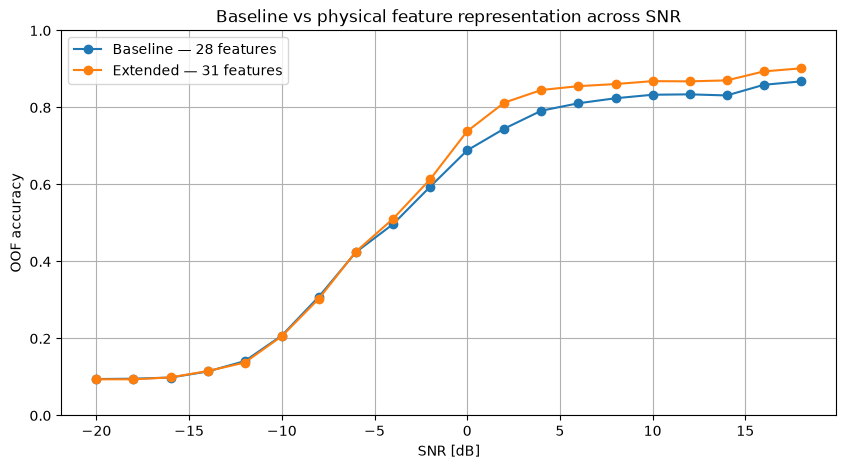

In [62]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    accuracy_by_snr["snr"],
    accuracy_by_snr["baseline_accuracy"],
    marker="o",
    label="Baseline — 28 features",
)

ax.plot(
    accuracy_by_snr["snr"],
    accuracy_by_snr["extended_accuracy"],
    marker="o",
    label="Extended — 31 features",
)

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("OOF accuracy")

ax.set_title(
    "Baseline vs physical feature representation across SNR"
)

ax.set_ylim(0, 1)

ax.grid(True)
ax.legend()

plt.show()

In [63]:
class_comparison_rows = []

for modulation in sorted(
    y_train.unique()
):

    group = comparison_df[
        comparison_df[
            "true_modulation"
        ]
        == modulation
    ]

    baseline_recall = np.mean(
        group[
            "baseline_prediction"
        ]
        == modulation
    )

    extended_recall = np.mean(
        group[
            "extended_prediction"
        ]
        == modulation
    )

    class_comparison_rows.append({
        "modulation": modulation,
        "baseline_recall":
            baseline_recall,
        "extended_recall":
            extended_recall,
        "difference":
            extended_recall
            - baseline_recall,
    })

recall_by_class = pd.DataFrame(
    class_comparison_rows
)

recall_by_class.sort_values(
    "difference",
    ascending=False,
).round(4)

,modulation,baseline_recall,extended_recall,difference
9,QPSK,0.4004,0.5089,0.1084
0,8PSK,0.3726,0.4671,0.0946
1,AM-DSB,0.5962,0.6109,0.0146
3,BPSK,0.5196,0.5321,0.0125
8,QAM64,0.4679,0.4797,0.0119
7,QAM16,0.4041,0.4108,0.0066
6,PAM4,0.6364,0.6423,0.0059
2,AM-SSB,0.9556,0.9580,0.0024
4,CPFSK,0.5504,0.5519,0.0014
5,GFSK,0.6160,0.6139,-0.0021


### 12.3 Conclusions — Full 11-class comparison

The selected physical descriptors produce a substantial improvement in
the complete 11-class AMC problem.

Using the same five cross-validation folds and Random Forest configuration,
the representation improves from:

- Accuracy: 0.5331 → 0.5557
- Macro-F1: 0.5510 → 0.5778

This corresponds to improvements of approximately 2.26 percentage points
in accuracy and 2.68 percentage points in macro-F1.

The largest class-specific gains occur precisely for the intended PSK
confusion:

- QPSK recall improves by approximately 10.8 percentage points;
- 8PSK recall improves by approximately 9.5 percentage points.

The improvement is strongly SNR dependent. Performance remains essentially
unchanged in the extreme low-SNR regime, while gains become substantial
from approximately 0 dB onward.

This behaviour is physically consistent with the fourth-order circular
moment requiring observable angular constellation structure.

The results provide strong evidence that physically motivated feature
engineering addresses a representation limitation that could not be solved
effectively through hyperparameter tuning or classifier specialization.

---

## 13. Ablation study of the selected physical features

The complete 31-feature representation improves the 11-class classifier
substantially.

However, the class-specific results suggest that most of the gain may be
associated with the fourth-order circular moment, while the two analog
features provide a substantially smaller contribution.

An ablation experiment is therefore performed using the same cross-validation
folds:

1. baseline: 28 features;
2. baseline + `circular_moment_4`;
3. baseline + analog physical features;
4. baseline + all three selected physical features.

The objective is to retain only features that provide measurable
end-to-end value.

In [64]:
psk_only_features = (
    baseline_feature_columns
    + [
        "circular_moment_4",
    ]
)

analog_only_features = (
    baseline_feature_columns
    + [
        "inst_freq_autocorr_lag1",
        "spectral_sideband_asymmetry",
    ]
)

X_psk_only = train_selected_features[
    psk_only_features
]

X_analog_only = train_selected_features[
    analog_only_features
]

print(
    "PSK-only feature count:",
    X_psk_only.shape[1]
)

print(
    "Analog-only feature count:",
    X_analog_only.shape[1]
)

PSK-only feature count: 29
Analog-only feature count: 30


In [65]:
psk_only_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

print(
    "Running 29-feature PSK-only model..."
)

psk_only_oof_predictions = cross_val_predict(
    psk_only_rf,
    X_psk_only,
    y_train,
    cv=cv_splits,
    method="predict",
    n_jobs=1,
)

print("Completed.")

Running 29-feature PSK-only model...
Completed.


In [66]:
analog_only_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

print(
    "Running 30-feature analog-only model..."
)

analog_only_oof_predictions = cross_val_predict(
    analog_only_rf,
    X_analog_only,
    y_train,
    cv=cv_splits,
    method="predict",
    n_jobs=1,
)

print("Completed.")

Running 30-feature analog-only model...
Completed.


In [67]:
def summarize_oof_model(
    name,
    predictions,
):
    return {
        "model": name,

        "n_features": {
            "Baseline": 28,
            "PSK only": 29,
            "Analog only": 30,
            "All selected": 31,
        }[name],

        "accuracy": accuracy_score(
            y_train,
            predictions,
        ),

        "macro_f1": f1_score(
            y_train,
            predictions,
            average="macro",
        ),
    }

In [68]:
ablation_summary = pd.DataFrame([
    summarize_oof_model(
        "Baseline",
        baseline_oof_predictions,
    ),

    summarize_oof_model(
        "PSK only",
        psk_only_oof_predictions,
    ),

    summarize_oof_model(
        "Analog only",
        analog_only_oof_predictions,
    ),

    summarize_oof_model(
        "All selected",
        extended_oof_predictions,
    ),
])

ablation_summary[
    "delta_accuracy"
] = (
    ablation_summary["accuracy"]
    - baseline_accuracy
)

ablation_summary[
    "delta_macro_f1"
] = (
    ablation_summary["macro_f1"]
    - baseline_f1
)

ablation_summary.round(4)

,model,n_features,accuracy,macro_f1,delta_accuracy,delta_macro_f1
0,Baseline,28,0.5331,0.5510,0.0000,0.0000
1,PSK only,29,0.5543,0.5765,0.0212,0.0256
2,Analog only,30,0.5343,0.5521,0.0012,0.0012
3,All selected,31,0.5557,0.5778,0.0226,0.0268


In [69]:
target_classes = [
    "QPSK",
    "8PSK",
    "WBFM",
    "AM-DSB",
]

In [70]:
ablation_predictions = {
    "Baseline":
        baseline_oof_predictions,

    "PSK only":
        psk_only_oof_predictions,

    "Analog only":
        analog_only_oof_predictions,

    "All selected":
        extended_oof_predictions,
}

ablation_recall_rows = []

for model_name, predictions in (
    ablation_predictions.items()
):

    for modulation in target_classes:

        mask = (
            y_train.to_numpy()
            == modulation
        )

        recall = np.mean(
            predictions[mask]
            == modulation
        )

        ablation_recall_rows.append({
            "model": model_name,
            "modulation": modulation,
            "recall": recall,
        })

ablation_recall = pd.DataFrame(
    ablation_recall_rows
)

ablation_recall.pivot(
    index="modulation",
    columns="model",
    values="recall",
).round(4)

model,All selected,Analog only,Baseline,PSK only
modulation,,,,
8PSK,0.4671,0.3716,0.3726,0.4683
AM-DSB,0.6109,0.6121,0.5962,0.5949
QPSK,0.5089,0.4053,0.4004,0.5065
WBFM,0.3375,0.3350,0.3447,0.3469


### 13.5 Final ablation conclusion

The ablation study shows that almost the entire improvement of the
physical feature representation is produced by a single descriptor:
`circular_moment_4`.

The 28-feature baseline reaches a macro-F1 of 0.5510.

Adding only `circular_moment_4` increases macro-F1 to 0.5765, an
improvement of approximately 2.56 percentage points.

Adding the two analog descriptors alone provides only a marginal
improvement (macro-F1 = 0.5521).

The complete 31-feature representation reaches macro-F1 = 0.5778, only
approximately 0.13 percentage points above the 29-feature PSK model.

The additional analog features therefore do not provide sufficient
end-to-end benefit to justify their inclusion.

The final candidate representation is consequently:

- the original 28 handcrafted features;
- `circular_moment_4`.

This produces a compact 29-feature representation with a strong physical
interpretation and a substantial improvement in QPSK/8PSK discrimination.

In [71]:
importlib.reload(
    rfml.features
)

<module 'rfml.features' from 'c:\\Users\\joset\\Projects\\snr-aware-modulation-classification\\src\\rfml\\features.py'>

In [72]:
final_features = (
    rfml.features.extract_features(
        sample,
        feature_set="full_final",
    )
)

print(
    "Final feature count:",
    len(final_features)
)

print(
    sorted(
        set(final_features)
        - set(baseline_features)
    )
)

Final feature count: 29
['circular_moment_4']


In [73]:
validation_metadata = pd.read_csv(
    PROCESSED_DIR
    / "validation_metadata.csv"
)

print(
    "Validation metadata:",
    validation_metadata.shape
)

validation_metadata.head()

Validation metadata: (33000, 4)


,sample_id,modulation,snr,array_index
0,163488,QAM64,-14,488
1,28582,AM-DSB,-4,582
2,28485,AM-DSB,-4,485
3,201977,WBFM,-18,977
4,70214,BPSK,0,214


---

## 14. Validation of the final 29-feature representation

The train-only experiments selected a final feature representation before
validation evaluation.

The final representation contains the original 28 handcrafted descriptors
plus the fourth-order circular moment.

No additional feature selection or architectural changes will be made based
on the validation result.

In [75]:
validation_final_features = (
    rfml.features.build_feature_table(
        radioml,
        validation_metadata,
        feature_set="full_final",
    )
)

print(
    "Validation feature table:",
    validation_final_features.shape
)

Validation feature table: (33000, 32)


In [76]:
final_feature_columns = [
    column
    for column in validation_final_features.columns
    if column not in [
        "sample_id",
        "modulation",
        "snr",
    ]
]

print(
    "Number of final features:",
    len(final_feature_columns)
)

values = validation_final_features[
    final_feature_columns
].to_numpy(dtype=float)

print(
    "All finite:",
    np.isfinite(values).all()
)

print(
    "NaN count:",
    np.isnan(values).sum()
)

print(
    "Inf count:",
    np.isinf(values).sum()
)

Number of final features: 29
All finite: True
NaN count: 0
Inf count: 0


In [77]:
validation_final_features.to_pickle(
    PROCESSED_DIR
    / "validation_final_29_features.pkl"
)

In [78]:
final_train_feature_columns = (
    baseline_feature_columns
    + ["circular_moment_4"]
)

X_train_final = train_selected_features[
    final_train_feature_columns
]

y_train_final = train_selected_features[
    "modulation"
]

X_validation_final = validation_final_features[
    final_train_feature_columns
]

y_validation_final = validation_final_features[
    "modulation"
]

print(
    X_train_final.shape,
    X_validation_final.shape
)

(154000, 29) (33000, 29)


In [79]:
final_29_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

final_29_rf.fit(
    X_train_final,
    y_train_final,
)

validation_29_predictions = (
    final_29_rf.predict(
        X_validation_final
    )
)

In [80]:
validation_29_accuracy = accuracy_score(
    y_validation_final,
    validation_29_predictions,
)

validation_29_f1 = f1_score(
    y_validation_final,
    validation_29_predictions,
    average="macro",
)

print(
    f"29-feature validation accuracy: "
    f"{validation_29_accuracy:.4f}"
)

print(
    f"29-feature validation macro-F1: "
    f"{validation_29_f1:.4f}"
)

29-feature validation accuracy: 0.5537
29-feature validation macro-F1: 0.5762


## 15. Final validation diagnostics

The 29-feature representation has been selected and is now frozen.

Its validation performance confirms the improvement observed during
train-only cross-validation.

The remaining analysis is descriptive only. No additional feature
selection, hyperparameter tuning or architectural changes will be made
based on these results.

The objective is to determine where the improvement occurs across SNR
and modulation classes before the final test evaluation.

In [81]:
validation_comparison_df = pd.DataFrame({
    "true_modulation":
        y_validation_final.to_numpy(),

    "snr":
        validation_final_features[
            "snr"
        ].to_numpy(),

    "extended_prediction":
        validation_29_predictions,
})

In [82]:
validation_snr_rows = []

for snr, group in (
    validation_comparison_df.groupby("snr")
):

    accuracy = accuracy_score(
        group["true_modulation"],
        group["extended_prediction"],
    )

    validation_snr_rows.append({
        "snr": snr,
        "accuracy": accuracy,
    })

validation_29_accuracy_by_snr = (
    pd.DataFrame(
        validation_snr_rows
    )
)

validation_29_accuracy_by_snr.round(4)

,snr,accuracy
0,-20,0.0988
1,-18,0.0964
2,-16,0.0976
3,-14,0.1145
4,-12,0.1412
5,-10,0.2103
6,-8,0.2988
7,-6,0.4218
8,-4,0.5055
9,-2,0.5921


In [83]:
validation_class_rows = []

for modulation in sorted(
    y_validation_final.unique()
):

    mask = (
        y_validation_final.to_numpy()
        == modulation
    )

    recall = np.mean(
        validation_29_predictions[
            mask
        ]
        == modulation
    )

    validation_class_rows.append({
        "modulation": modulation,
        "recall": recall,
    })

validation_29_recall_by_class = (
    pd.DataFrame(
        validation_class_rows
    )
)

validation_29_recall_by_class.sort_values(
    "recall",
    ascending=False,
).round(4)

,modulation,recall
2,AM-SSB,0.9450
6,PAM4,0.6430
5,GFSK,0.6203
1,AM-DSB,0.5943
4,CPFSK,0.5533
3,BPSK,0.5360
9,QPSK,0.5113
8,QAM64,0.4803
0,8PSK,0.4640
7,QAM16,0.4047


In [84]:
from sklearn.metrics import confusion_matrix

snr_to_inspect = 18

mask_18 = (
    validation_final_features[
        "snr"
    ].to_numpy()
    == snr_to_inspect
)

y_true_18 = (
    y_validation_final.to_numpy()[
        mask_18
    ]
)

y_pred_18 = (
    validation_29_predictions[
        mask_18
    ]
)

classes = final_29_rf.classes_

cm_18 = confusion_matrix(
    y_true_18,
    y_pred_18,
    labels=classes,
    normalize="true",
)

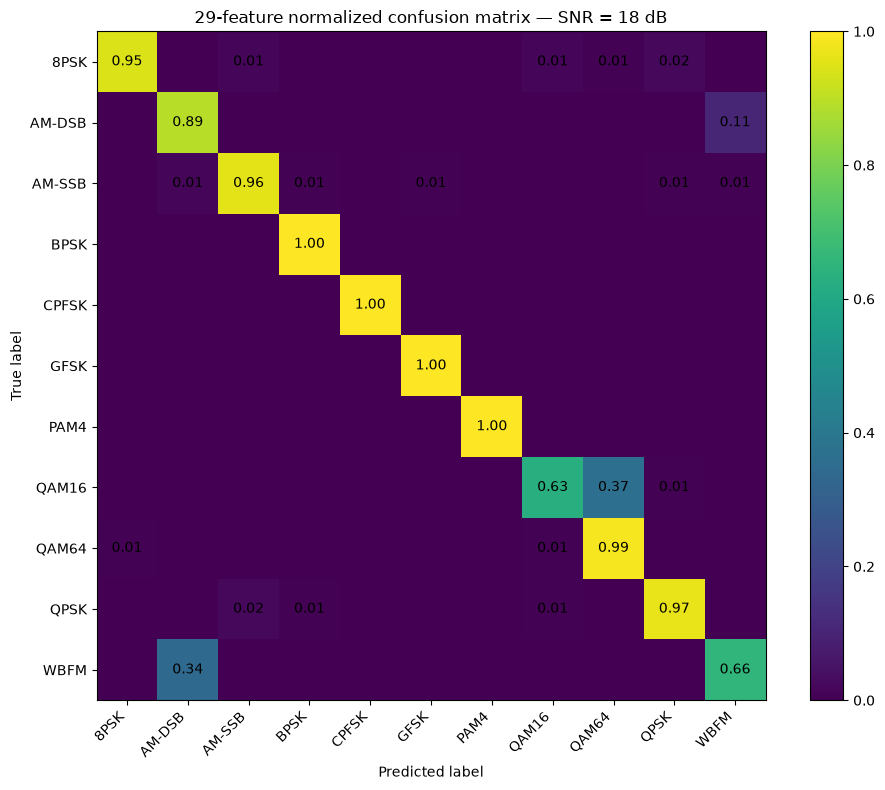

In [85]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    cm_18,
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    np.arange(len(classes))
)

ax.set_yticks(
    np.arange(len(classes))
)

ax.set_xticklabels(
    classes,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    classes
)

for i in range(len(classes)):
    for j in range(len(classes)):

        value = cm_18[i, j]

        if value > 0.005:
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
            )

ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "29-feature normalized confusion matrix — SNR = 18 dB"
)

fig.colorbar(
    image,
    ax=ax,
)

plt.tight_layout()
plt.show()

### 15.4 Final validation conclusion

The final 29-feature representation confirms the improvement observed
during train-only cross-validation.

Validation performance improves from:

- Accuracy: 0.5314 → 0.5537
- Macro-F1: 0.5493 → 0.5762

The validation macro-F1 (0.5762) is almost identical to the out-of-fold
training estimate (0.5765), indicating that the observed improvement
generalizes consistently beyond the development folds.

The largest structural improvement occurs in the intended PSK ambiguity.

At 18 dB:

- 8PSK recall increases from approximately 0.79 to 0.95;
- QPSK recall increases from approximately 0.81 to 0.97.

The QPSK/8PSK confusion is therefore largely removed at high SNR.

The improvement is concentrated in medium and high SNR, where angular
constellation structure is observable, while the extreme low-SNR regime
remains fundamentally difficult.

QAM16/QAM64 and WBFM/AM-DSB remain the principal high-SNR confusions.
Previous experiments showed that the evaluated additional feature blocks
and specialist architectures do not provide sufficient end-to-end benefit
to justify further complexity.

The model design is therefore frozen at this point.